# 🏭 Fase 1: Análisis Exploratorio (EDA) - AI4I 2020 Predictive Maintenance

En este notebook exploraremos el dataset **AI4I 2020** provisto por el repositorio UCI. Este dataset contiene registros simulados de telemetría de una máquina de fresado industrial, con el objetivo de predecir fallos inminentes basados en temperatura, desgaste, fuerza (torque) y velocidad.

### Objetivos del EDA:
1. Entender la distribución de las variables operativas.
2. Analizar el desbalance de clases (los fallos son eventos raros).
3. Crear nuevas variables (Feature Engineering) que puedan tener poder predictivo para nuestros modelos posteriores (Autoencoder y XGBoost).

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background') # Estilo industrial oscuro
sns.set_palette("viridis")

## 1. Carga y Exploración Inicial

In [7]:
# Cargar dataset
df = pd.read_csv('../data/ai4i2020.csv')
print(f"Forma del dataset: {df.shape}")
df.head()

Forma del dataset: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [8]:
# Limpieza básica: Eliminar columnas de ID que no aportan valor predictivo
df_clean = df.drop(['UDI', 'Product ID'], axis=1)
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Type                     10000 non-null  object 
 1   Air temperature [K]      10000 non-null  float64
 2   Process temperature [K]  10000 non-null  float64
 3   Rotational speed [rpm]   10000 non-null  int64  
 4   Torque [Nm]              10000 non-null  float64
 5   Tool wear [min]          10000 non-null  int64  
 6   Machine failure          10000 non-null  int64  
 7   TWF                      10000 non-null  int64  
 8   HDF                      10000 non-null  int64  
 9   PWF                      10000 non-null  int64  
 10  OSF                      10000 non-null  int64  
 11  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 937.6+ KB


## 2. Análisis del Desbalance de Clases
La variable objetivo global es `Machine failure`. Adicionalmente tenemos los modos específicos: `TWF`, `HDF`, `PWF`, `OSF`, `RNF`.

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='Machine failure', palette=['#2ecc71', '#e74c3c'])
plt.title('Distribución de Estado de Máquina (Normal vs Falla)')
plt.ylabel('Cantidad de Registros')

fallas = df_clean['Machine failure'].sum()
print(f"Total de fallas: {fallas} ({fallas/len(df_clean)*100:.2f}%)")

Total de fallas: 339 (3.39%)


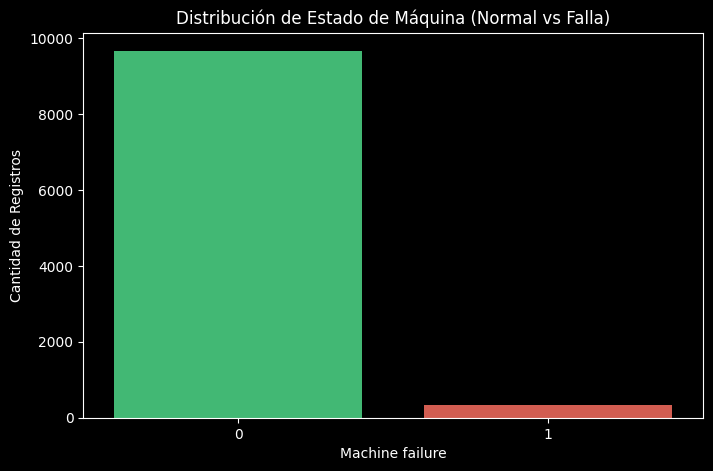

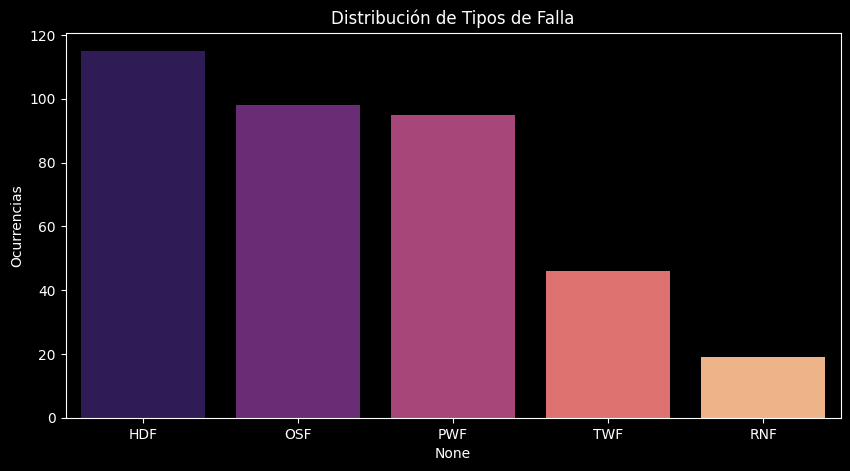

In [10]:
# Desglose por tipo de falla
falla_tipos = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
conteo_fallas = df_clean[falla_tipos].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=conteo_fallas.index, y=conteo_fallas.values, palette='magma')
plt.title('Distribución de Tipos de Falla')
plt.ylabel('Ocurrencias')
plt.show()

## 3. Feature Engineering (Ingeniería de Características)
Creamos variables derivadas con significado físico para la máquina.

In [11]:
df_fe = df_clean.copy()

# 1. Delta Temperatura (Diferencia entre proceso y ambiente)
df_fe['delta_temp'] = df_fe['Process temperature [K]'] - df_fe['Air temperature [K]']

# 2. Potencia Mecánica Estimada (Torque * RPM)
# Fórmula real: P(kW) = Torque(Nm) * RPM / 9550
df_fe['power_kw'] = (df_fe['Torque [Nm]'] * df_fe['Rotational speed [rpm]']) / 9550

# 3. Interacción Desgaste-Torque (Esfuerzo)
df_fe['wear_torque'] = df_fe['Tool wear [min]'] * df_fe['Torque [Nm]']

df_fe[['delta_temp', 'power_kw', 'wear_torque']].describe()

,delta_temp,power_kw,wear_torque
count,10000.000000,10000.000000,10000.000000
mean,10.000630,6.279282,4314.664550
std,1.001094,1.067340,2826.567692
min,7.600000,1.148356,0.000000
25%,9.300000,5.560775,1963.650000
50%,9.800000,6.270565,4012.950000
75%,11.000000,7.002487,6279.000000
max,12.100000,10.469152,16497.000000


## 4. Correlaciones
Verifiquemos cómo las nuevas features se relacionan con las fallas.

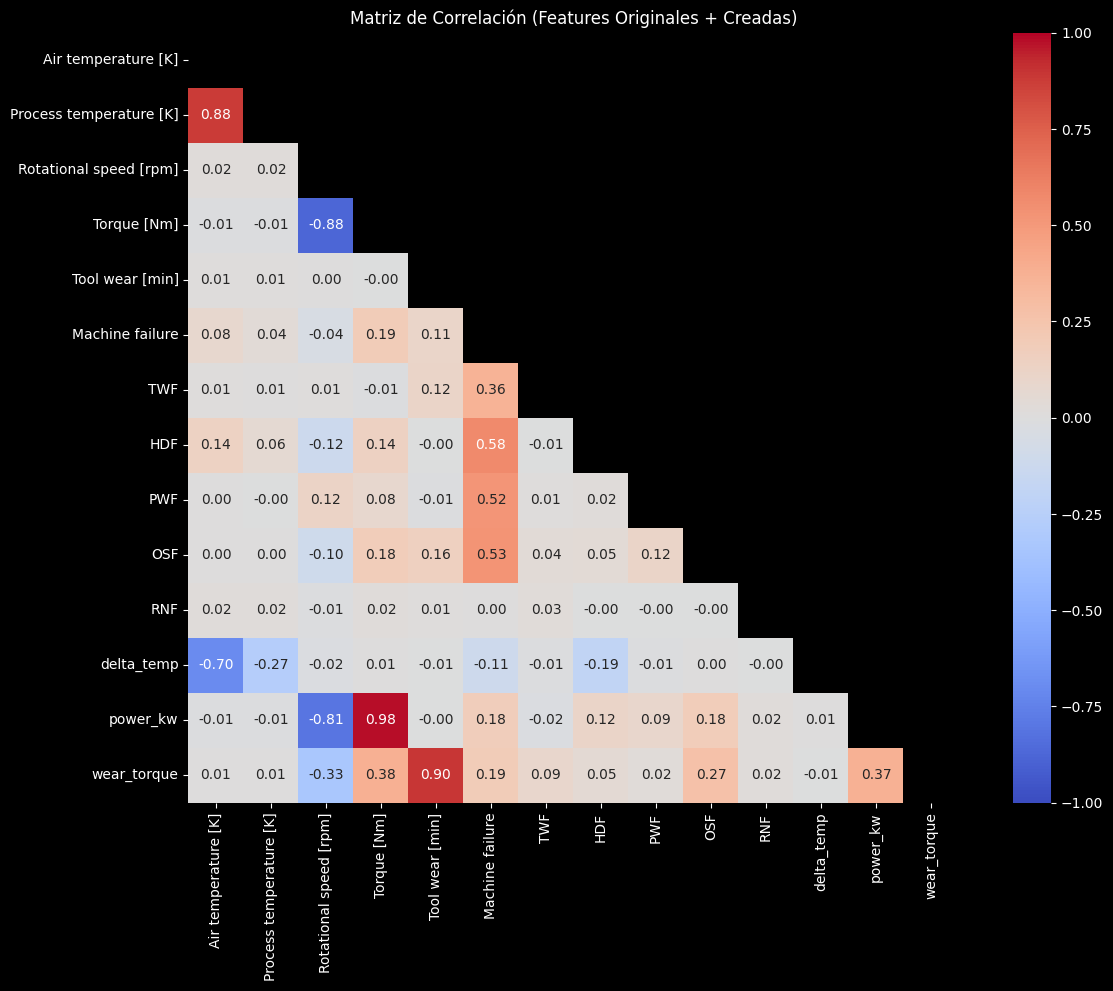

In [12]:
numeric_df = df_fe.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Matriz de Correlación (Features Originales + Creadas)')
plt.show()

### Conclusiones del EDA:
1. Hay un claro **desbalance de clases** (~3.4% de fallas) que deberemos manejar con SMOTE o `scale_pos_weight` en XGBoost.
2. Las fallas de sobreesfuerzo (`OSF`), disipación de calor (`HDF`) y potencia (`PWF`) son las más comunes.
3. Features como `delta_temp` están altamente correlacionadas con la probabilidad de `HDF`.
4. El dataset está listo para ser utilizado en el entrenamiento del modelo de Clasificación (Siguiente Notebook).

In [13]:
# Exportamos el dataset enriquecido para el próximo paso
df_fe.to_csv('../data/ai4i2020_fe.csv', index=False)
print("Dataset con features exportado exitosamente a 'data/ai4i2020_fe.csv'")

Dataset con features exportado exitosamente a 'data/ai4i2020_fe.csv'
